In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import requests
import torch
from PIL import Image
import numpy as np
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from transformers import MllamaForConditionalGeneration, AutoProcessor

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

from src.agents.tools.comm import EncodingTool, DecodingTool

from src.kitti_tracking import KittiDataset

In [3]:
model_id = "meta-llama/Llama-3.2-11B-Vision"

model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(model_id)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

clip_segm_name = "CIDAS/clipseg-rd64-refined"
clip_segm_processor = CLIPSegProcessor.from_pretrained(clip_segm_name, use_fast=True)
clip_segm_model = CLIPSegForImageSegmentation.from_pretrained(clip_segm_name).to(device)

encoding_tool = EncodingTool("https://cdn.openai.com/dall-e/encoder.pkl")
deocding_tool = DecodingTool("https://cdn.openai.com/dall-e/decoder.pkl")

In [3]:
root_dir = "C:/Users/ngoak/data/kitti_tracking"
n_steps, n_pred_steps = 16, 3

train_ds = KittiDataset(root_dir, "training", n_steps, n_pred_steps)

In [19]:
prompt = ["person"]

for sample in train_ds:
	frames, _ = sample
	break

In [ ]:
with torch.no_grad():
	gt_sem_masks = []
	codewords = []
	gt_sem_prompts = []
	for frame in frames:
		clip_segm_inputs = clip_segm_processor(
			images=frame,
			text=prompt,
			padding=True,
			truncation=True,
			return_tensors="pt"
		).to(device)
		clip_segm_outputs = clip_segm_model(**clip_segm_inputs)

		gt_sem_mask = clip_segm_outputs.logits.amax(0).sigmoid().float().cpu().numpy()
		gt_sem_mask = Image.fromarray((gt_sem_mask > 0.5).astype(np.uint8) * 255).resize(frames[0].size)
		
		gt_sem_masks.append(gt_sem_mask)

		codeword = encoding_tool(gt_sem_mask)
		recon_sem_mask = deocding_tool(codeword)
		codewords.append(codeword)

		gt_sem_prompt = "<begin_of_mask>" + "".join([
			f"<mask_{word}>"
			for words in codeword[0].cpu().tolist()
			for word in words
		]) + "<end_of_mask>"
		gt_sem_prompts.append(gt_sem_prompt)

In [67]:
codeword.shape

torch.Size([1, 46, 155])

In [35]:
start_idx = gt_sem_prompt.index("<begin_of_mask>")
end_idx = gt_sem_prompt.index("<end_of_mask>")

In [62]:
# gt_sem_prompt[start_idx+len("<begin_of_mask>"):]
mask_prompt = gt_sem_prompt[start_idx+len("<begin_of_mask>")+1:end_idx-1].split("><")

mask_codewords = [
    int(prompt[prompt.index("_")+1:])
    for prompt in mask_prompt
]

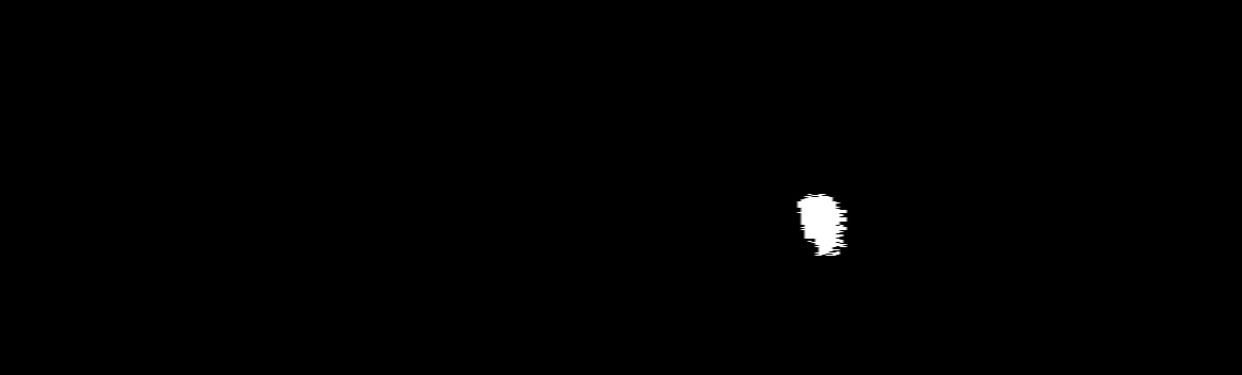

In [73]:
gt_sem_mask

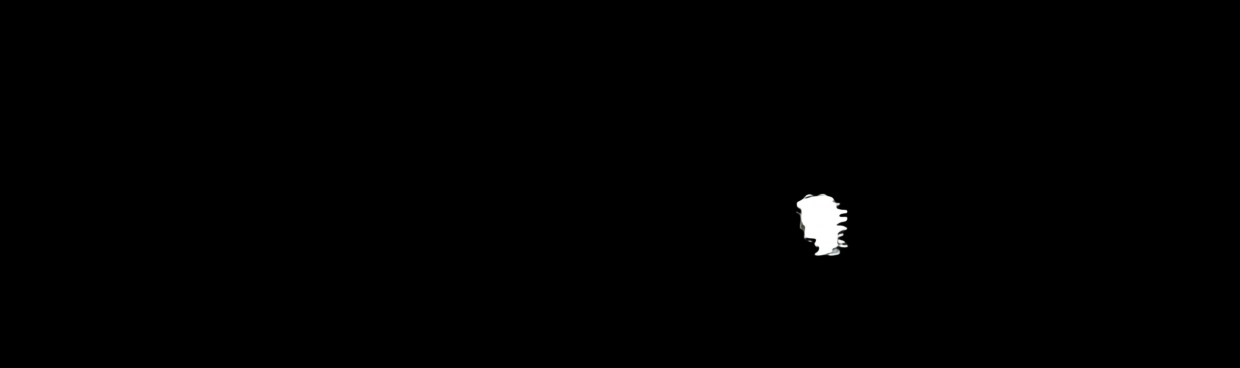

In [71]:
received_codewords = torch.LongTensor(mask_codewords).unsqueeze(0)
received_codewords = received_codewords.reshape((1, 46, 155))

_recon_sem_mask = deocding_tool(received_codewords.to(device))
_recon_sem_mask

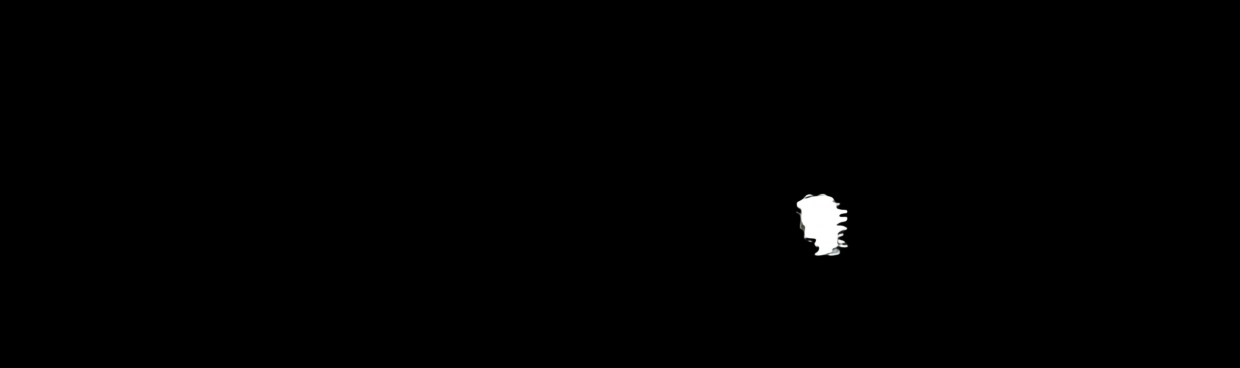

In [72]:
recon_sem_mask

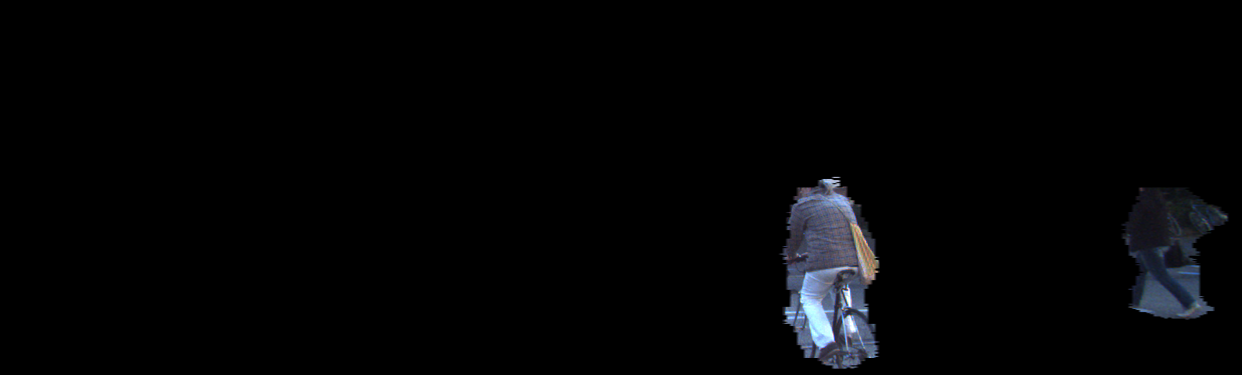

In [74]:
result = Image.composite(
    frames[0],
    Image.new("RGB", frames[0].size, (0, 0, 0)),
    gt_sem_masks[0]
)

result